In [27]:
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Tuple

# Opcional: solver de referència (implementació de biblioteca)
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from QPGC import QPGenericConstraints


## Theoretical Background

For understand correctly the objectives of this practical delivery, we must take into account the following theorical approach for implement Support Vector Machines (SVMs) classifiers, most of those concepts had been explaind on Practical 5 and the update of Practical 6 concerns to optimization method needed to solve the unconstrained primal problem by Stochastic Gradient Descent and mini-batch approach. So, just remembering from last practical lesson, SVMs are supervised learning methods designed to address binary classification problems by constructing a separating hyperplane with maximum margin. 

In this case, given a training dataset $\{(x_i, y_i)\}_{i=1}^m$ with input vectors $x_i \in \mathbb{R}^n$ and labels $y_i \in \{-1, +1\}$, the objective is not only to correctly classify the samples but to do so in a way that maximizes robustness and generalization. This robustness is achieved by maximizing the margin, understood as the minimum distance between the separating hyperplane and the closest data points from each class.

In the linearly separable case, the classifier is defined by the affine function 

$$ f(x) = w^T x + b $$

where $w$ is the normal vector to the hyperplane and $b$ is a bias term. Correct classification with a margin constraint requires that all training samples satisfy 

$$y_i (w^T x_i + b) \geq 1$$

The margin corresponds to the distance between the two parallel hyperplanes $f(x) = 1$ and $f(x) = -1$, which can be shown to be equal to $2 / \|w\|$. Therefore, maximizing the margin is equivalent to minimizing the squared Euclidean norm of the weight vector.

This leads to the primal optimization problem:

$$\min_{w,b} \frac{1}{2}\|w\|^2 \quad \text{subject to} \quad y_i (w^T x_i + b) \geq 1$$

This is a convex optimization problem with linear inequality constraints. Instead of solving it directly, it is advantageous to derive its dual formulation using the method of Lagrange multipliers. Introducing multipliers $\alpha_i \geq 0$ associated with each constraint, the Lagrangian is defined as 

$$\mathcal{L}(w,b,\alpha) = \frac{1}{2}\|w\|^2 - \sum_{i=1}^m \alpha_i \left(y_i (w^T x_i + b) - 1\right)$$

The optimal solution corresponds to a saddle point of this Lagrangian. Enforcing stationarity with respect to $w$ and $b$ yields the conditions $$w = \sum_{i=1}^m \alpha_i y_i x_i$$ and $$\sum_{i=1}^m \alpha_i y_i = 0$$

These relations reveal a fundamental property of SVMs: the optimal separating hyperplane is entirely determined by a subset of the training samples, namely those with strictly positive multipliers. These samples are called support vectors and lie on or within the margin boundaries.

Substituting the stationarity conditions back into the Lagrangian leads to the dual optimization problem 

$$\max_{\alpha} \sum_{i=1}^m \alpha_i - \frac{1}{2} \sum_{i=1}^m \sum_{j=1}^m \alpha_i \alpha_j y_i y_j x_i^T x_j \quad \text{subject to} \quad \sum_{i=1}^m \alpha_i y_i = 0,\; \alpha_i \geq 0$$

This problem is a quadratic program with a linear equality constraint and non-negativity constraints. Since the objective function is concave, the solution is unique and corresponds to the global optimum. In practical scenarios, data are rarely perfectly separable. To account for this, slack variables $\xi_i \geq 0$ are introduced, allowing violations of the margin constraints. The primal problem becomes 

$$\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + K \sum_{i=1}^m \xi_i \quad \text{subject to} \quad y_i (w^T x_i + b) \geq 1 - \xi_i,\; \xi_i \geq 0$$

where the regularization parameter $K > 0$ controls the trade-off between maximizing the margin and penalizing classification errors.

The dual formulation in the non-separable case introduces upper bounds on the Lagrange multipliers, leading to $$\max_{\alpha} \sum_{i=1}^m \alpha_i - \frac{1}{2} \alpha^T (Y X^T X Y) \alpha \quad \text{subject to} \quad \sum_{i=1}^m \alpha_i y_i = 0,\; 0 \leq \alpha_i \leq K$$

This constrained quadratic optimization problem fits naturally within the framework of numerical linear algebra and can be solved efficiently using methods based on the Karush–Kuhn–Tucker conditions.

Once the optimal multipliers $\alpha^\star$ are obtained, the parameters of the classifier are reconstructed. The weight vector is computed as

$$w = \sum_{i=1}^m \alpha_i^\star y_i x_i $$

while the bias term can be estimated using any support vector satisfying $0 < \alpha_i < K$ through the relation $b = y_i - w^T x_i$. When several such support vectors exist, averaging the resulting values of $b$ improves numerical stability. Finally, the classifier is analyzed geometrically by visualizing the decision boundary $f(x) = 0$ together with the margin hyperplanes $f(x) = \pm 1$, which confirms that the support vectors lie exactly on the margin and illustrates the influence of the regularization parameter $K$ in both separable and non-separable cases.

In previous work, it has been shown that many constrained optimization problems, including the SVM, admit a **dual formulation**. Solving the dual problem can be advantageous because it may be easier to optimize and, in the case of SVMs, it allows the problem to be expressed solely in terms of inner products. This property enables the use of kernel functions, making nonlinear classification possible. Moreover, under mild regularity conditions, the optimal solution of the dual problem uniquely determines the solution of the primal problem.

Despite these advantages, working in the dual is not strictly necessary for solving the SVM. In fact, the primal formulation can be solved efficiently by rewriting it as an unconstrained optimization problem. Eliminating the slack variables $\xi_i$ leads to the following equivalent **primal hinge-loss formulation**
$$
f(w,b) = \frac{1}{2} w^\top w + K \sum_{i=1}^m \max\bigl(0,, 1 - y_i(w^\top x_i + b)\bigr)
$$
This formulation directly penalizes samples that violate the margin through the hinge loss, while samples correctly classified with margin greater than one do not contribute to the loss.

For numerical stability, the lab adopts a rescaled version of this objective:
$$
f(w,b) = \frac{\lambda}{2} w^\top w + \sum_{i=1}^m \max\bigl(0,, 1 - y_i(w^\top x_i + b)\bigr)
$$
where $\lambda$ is a small positive parameter, typically related to $K$ by $K \approx 1/\lambda$. This is the objective function that will be minimized throughout the experiments.

Although this function is convex, it is not differentiable everywhere due to the hinge loss. As a consequence, optimization methods based on **subgradients** must be used. A straightforward approach would be to apply gradient or Newton-type methods using the full dataset, but this becomes computationally expensive as the number of samples grows.

To address this issue, the lab proposes the use of **Stochastic Gradient Descent (SGD)**. Instead of computing the subgradient using all $m$ samples, SGD approximates it at each iteration using a single randomly selected sample $(x_t, y_t)$. This leads to update rules of the form
$$
w_{t+1} = w_t - \gamma_t
\begin{cases}
\lambda w_t, & \text{if } y_t\bigl(w_t^\top x_t + b_t\bigr) > 1, \\
\lambda w_t - y_t x_t, & \text{otherwise}.
\end{cases}
$$

and
$$
b_{t+1} = b_t - \gamma_t
\begin{cases}
  0, & \text{if } y_t(w_t^\top x_t + b_t) > 1, \\
  - y_t, & \text{otherwise}.
  \end{cases}
  $$
  Because the gradient estimate is noisy, the objective function may temporarily increase from one iteration to the next. Nevertheless, under suitable conditions and with a decreasing learning rate $\gamma_t$, SGD is guaranteed to converge to the global minimum of this convex problem.

A common choice for the learning rate is $\gamma_t = 1/\mu_t$, where $\mu_t$ increases with the iteration index $t$. This schedule allows for large exploratory steps at the beginning of training and progressively smaller steps as the algorithm approaches the optimum. The convergence speed of SGD is fundamentally limited by the variance of the stochastic gradient, and theoretical results show that the best asymptotic convergence rate is achieved when $\gamma_t \sim t^{-1}$.

An intermediate approach between full-batch gradient descent and classical SGD is **mini-batch stochastic gradient descent**. In this case, the subgradient is computed using a small subset $S$ of $M$ samples at each iteration. The update rules become
$$
w_{t+1} = w_t - \gamma_t \left( \lambda w_t + \sum_{k\in S}
\begin{cases}
0, & y_k(w_t^\top x_k + b_t) > 1, \\

- y_k x_k, & \text{otherwise},
  \end{cases}
  \right)
  $$
  and an analogous expression for $b_{t+1}$. Mini-batching reduces the variance of the gradient estimate compared to single-sample SGD, while still being computationally cheaper than using the full dataset.

In this laboratory, classical SGD, mini-batch SGD, and full gradient descent (which corresponds to using a mini-batch containing all samples) are compared by analyzing the evolution of the objective function $f(w,b)$. In particular, plotting $\log f(w,b)$ as a function of the training epoch provides a clear visualization of the convergence speed and stability of each optimization strategy.


In [49]:
### Main functions ###

def create_dataset(m1, s1, m2, s2, n_samples=100, seed=None):
    """
    Create a binary classification dataset with two classes sampled from 
    multivariate normal distributions.
    
    Parameters
    ----------
    m1 : array-like
        Mean vector for class 1
    s1 : array-like
        Covariance matrix for class 1
    m2 : array-like
        Mean vector for class 2
    s2 : array-like
        Covariance matrix for class 2
    n_samples : int, optional
        Number of samples per class (default: 100)
    seed : int, optional
        Random seed for reproducibility (default: None)
    
    Returns
    -------
    X : ndarray of shape (2*n_samples, 2)
        Feature matrix with all data points
    y : ndarray of shape (2*n_samples,)
        Labels: +1 for class 1, -1 for class 2
    """
    if seed is not None:
        np.random.seed(seed)
    X1 = np.random.multivariate_normal(m1, s1, n_samples)
    y1 = np.ones(n_samples)
    X2 = np.random.multivariate_normal(m2, s2, n_samples)
    y2 = -np.ones(n_samples)
    X = np.vstack([X1, X2])
    y = np.concatenate([y1, y2])
    return X, y

def SVM_stochastic_gradient(X, y, lambda_reg=1e-4, max_epochs=100, mu_init=100, mu_increment=1.0, verbose=True):
    """
    Train an SVM using Stochastic Gradient Descent on the primal problem.
    
    The optimization problem is:
        minimize: f(w, b) = (λ/2) * w^T w + Σ max(0, 1 - y_i(w^T x_i + b))
    
    This function implements the stochastic gradient descent algorithm where:
    - At each iteration, a single randomly picked example is used to estimate the gradient
    - The samples are shuffled at the beginning of each epoch
    - The learning rate γ_t = 1/μ_t, where μ_t increases after each iteration
    
    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
        Feature matrix.
    y : ndarray of shape (n_samples,)
        Labels (+1 or -1).
    lambda_reg : float, optional
        Regularization parameter λ (default: 1e-4).
        This corresponds to the penalty weight for the margin violations.
        Small values (e.g., 1e-4) are recommended for numerical stability.
    max_epochs : int, optional
        Maximum number of epochs (default: 100).
        Each epoch goes through all samples once in random order.
    mu_init : float, optional
        Initial value of μ for computing learning rate γ_t = 1/μ_t (default: 100).
        Smaller values give larger initial learning rates.
    mu_increment : float, optional
        Amount by which μ is increased after each iteration (default: 1.0).
        This controls how fast the learning rate decreases.
    verbose : bool, optional
        If True, print progress information (default: True).
        
    Returns
    -------
    w : ndarray of shape (n_features,)
        Weight vector of the separating hyperplane.
    b : float
        Bias term.
    history : dict
        Dictionary containing:
        - 'loss': list of objective function values at each epoch
        - 'w_norm': list of ||w||^2 values at each epoch
    """
    n_samples, n_features = X.shape
    
    # Initialize parameters
    w = np.zeros(n_features)
    b = 0.0
    mu = mu_init
    
    # History for tracking convergence
    history = {'loss': [], 'w_norm': []}
    
    # Main training loop over epochs
    for epoch in range(max_epochs):
        # Shuffle the dataset at the beginning of each epoch
        indices = np.random.permutation(n_samples)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        # Go through all samples in this epoch
        for i in range(n_samples):
            # Get current sample
            x_i = X_shuffled[i]
            y_i = y_shuffled[i]
            
            # Compute margin: y_i * (w^T x_i + b)
            margin = y_i * (np.dot(w, x_i) + b)
            
            # Compute learning rate for this iteration
            gamma = 1.0 / mu
            
            # Update rule: check if point violates margin (margin <= 1)
            if margin <= 1.0:
                # Point violates margin: apply gradient update
                # Gradient w.r.t. w: λw - y_i * x_i (when violating)
                w = w - gamma * (lambda_reg * w - y_i * x_i)
                # Gradient w.r.t. b: -y_i (when violating)
                b = b - gamma * (-y_i)
            else:
                # Point satisfies margin: only update w with regularization term
                w = w - gamma * (lambda_reg * w)
                # b doesn't change when margin is satisfied
        
        
        # Compute objective function value at end of epoch
        # f(w, b) = (λ/2) * w^T w + Σ max(0, 1 - y_i(w^T x_i + b))
        w_norm_sq = np.dot(w, w)
        hinge_loss = np.sum(np.maximum(0, 1 - y * (X @ w + b)))
        objective = (lambda_reg / 2.0) * w_norm_sq + hinge_loss

        # Increase μ after each iteration (decreases learning rate)
        mu += mu_increment
        
        history['loss'].append(objective)
        history['w_norm'].append(w_norm_sq)
        
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}/{max_epochs}: Loss = {objective:.6f}, ||w||^2 = {w_norm_sq:.6f}")
    
    return w, b, history

def SVM_minibatch_gradient(X, y, batch_size=10, lambda_reg=1e-4, max_epochs=100, mu_init=100, mu_increment=1.0, verbose=True):
    """
    Train an SVM using Mini-batch Stochastic Gradient Descent on the primal problem.
    
    The optimization problem is:
        minimize: f(w, b) = (λ/2) * w^T w + Σ max(0, 1 - y_i(w^T x_i + b))
    
    This function implements the mini-batch stochastic gradient descent algorithm where:
    - At each iteration, a mini-batch of M randomly picked examples is used to estimate the gradient
    - The samples are shuffled at the beginning of each epoch, then divided into mini-batches
    - The learning rate γ_t = 1/μ_t, where μ_t increases after each iteration
    
    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
        Feature matrix.
    y : ndarray of shape (n_samples,)
        Labels (+1 or -1).
    batch_size : int, optional
        Size of each mini-batch M (default: 10).
        The dataset is divided into mini-batches of this size.
    lambda_reg : float, optional
        Regularization parameter λ (default: 1e-4).
        This corresponds to the penalty weight for the margin violations.
        Small values (e.g., 1e-4) are recommended for numerical stability.
    max_epochs : int, optional
        Maximum number of epochs (default: 100).
        Each epoch processes all samples once through mini-batches.
    mu_init : float, optional
        Initial value of μ for computing learning rate γ_t = 1/μ_t (default: 100).
        Smaller values give larger initial learning rates.
    mu_increment : float, optional
        Amount by which μ is increased after each iteration (default: 1.0).
        This controls how fast the learning rate decreases.
    verbose : bool, optional
        If True, print progress information (default: True).
        
    Returns
    -------
    w : ndarray of shape (n_features,)
        Weight vector of the separating hyperplane.
    b : float
        Bias term.
    history : dict
        Dictionary containing:
        - 'loss': list of objective function values at each epoch
        - 'w_norm': list of ||w||^2 values at each epoch
    """
    n_samples, n_features = X.shape
    
    # Initialize parameters
    w = np.zeros(n_features)
    b = 0.0
    mu = mu_init
    
    # History for tracking convergence
    history = {'loss': [], 'w_norm': []}
    
    # Compute number of batches per epoch
    n_batches = (n_samples + batch_size - 1) // batch_size  # Ceiling division
    
    # Main training loop over epochs
    for epoch in range(max_epochs):
        # Shuffle the dataset at the beginning of each epoch
        indices = np.random.permutation(n_samples)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        # Process data in mini-batches
        for batch_idx in range(n_batches):
            # Get batch indices
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, n_samples)
            batch_indices = np.arange(start_idx, end_idx)
            
            # Get batch data
            X_batch = X_shuffled[batch_indices]
            y_batch = y_shuffled[batch_indices]
            batch_size_actual = len(batch_indices)
            
            # Compute learning rate for this iteration
            gamma = 1.0 / mu
            
            # Accumulate gradients over the mini-batch
            grad_w_sum = np.zeros(n_features)
            grad_b_sum = 0.0
            
            # Compute gradients for each sample in the batch
            for i in range(batch_size_actual):
                x_i = X_batch[i]
                y_i = y_batch[i]
                
                # Compute margin: y_i * (w^T x_i + b)
                margin = y_i * (np.dot(w, x_i) + b)
                
                # Update rule: check if point violates margin (margin <= 1)
                if margin <= 1.0:
                    # Point violates margin: contribute to gradient
                    # Gradient w.r.t. w: -y_i * x_i (when violating)
                    grad_w_sum += -y_i * x_i
                    # Gradient w.r.t. b: -y_i (when violating)
                    grad_b_sum += -y_i
            
            # Update parameters: add regularization term for w, then apply gradient step
            # For w: λw + (1/M) * Σ grad_w
            w = w - gamma * (lambda_reg * w + grad_w_sum)
            # For b: (1/M) * Σ grad_b
            b = b - gamma * (grad_b_sum)
        
        # Compute objective function value at end of epoch
        # f(w, b) = (λ/2) * w^T w + Σ max(0, 1 - y_i(w^T x_i + b))
        w_norm_sq = np.dot(w, w)
        hinge_loss = np.sum(np.maximum(0, 1 - y * (X @ w + b)))
        objective = (lambda_reg / 2.0) * w_norm_sq + hinge_loss

        # Increase μ after each iteration (decreases learning rate)
        mu += mu_increment
        
        history['loss'].append(objective)
        history['w_norm'].append(w_norm_sq)
        
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}/{max_epochs}: Loss = {objective:.6f}, ||w||^2 = {w_norm_sq:.6f}, Batch size = {batch_size}")
    
    return w, b, history



In [50]:
### Plotting functions ###

def plot_dataset(X, y, ax=None, title="Classification Dataset"):
    """
    Plot the dataset with different colors and shapes for each class.
    
    Parameters
    ----------
    X : ndarray of shape (n_samples, 2)
        Feature matrix
    y : ndarray of shape (n_samples,)
        Labels: +1 for class 1, -1 for class 2
    ax : matplotlib.axes.Axes, optional
        Axes to plot on (default: creates new figure)
    title : str, optional
        Title for the plot (default: "Classification Dataset")
    
    Returns
    -------
    ax : matplotlib.axes.Axes
        The axes with the plot
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    mask1 = y == 1
    ax.scatter(X[mask1, 0], X[mask1, 1], c='blue', marker='o', s=50, alpha=0.7, label='Class +1', edgecolors='darkblue')
    mask2 = y == -1
    ax.scatter(X[mask2, 0], X[mask2, 1], c='red', marker='s', s=50, alpha=0.7, label='Class -1', edgecolors='darkred')
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='datalim')
    return ax

def plot_svm_with_margin(X, y, w, b, ax=None, title="SVM with Margin"):
    """
    Plot a 2D dataset together with the SVM decision boundary and margin lines.

    The plot is automatically centered on the data points, and the decision
    boundary along with its margins is drawn to span the full visible plot
    area for consistent scaling.

    Parameters
    ----------
    X : ndarray of shape (n_samples, 2)
        Input feature matrix containing 2D points.
    y : ndarray of shape (n_samples,)
        Class labels for each sample, expected to be +1 or -1.
    w : ndarray of shape (2,)
        Weight vector defining the SVM separating hyperplane.
    b : float
        Bias (intercept) term of the separating hyperplane.
    ax : matplotlib.axes.Axes, optional
        Existing matplotlib axes to plot on. If None, a new figure and axes
        are created.
    title : str, optional
        Title displayed at the top of the plot.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The matplotlib axes object containing the plot.
    """
     
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    plot_dataset(X, y, ax=ax)

    # ---- Compute data-based limits with padding ----
    pad = 0.15
    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()

    x_range = x_max - x_min
    y_range = y_max - y_min

    x_min -= pad * x_range
    x_max += pad * x_range
    y_min -= pad * y_range
    y_max += pad * y_range

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # ---- Plot hyperplane and margins across full axes ----
    if abs(w[1]) > 1e-8:
        xx = np.array([x_min, x_max])

        # Decision boundary
        yy = (-w[0] * xx - b) / w[1]
        ax.plot(xx, yy, 'k-', linewidth=2, label='SVM hyperplane')

        # Margins
        yy_p = (-w[0] * xx - b + 1) / w[1]
        yy_m = (-w[0] * xx - b - 1) / w[1]

        ax.plot(xx, yy_p, 'b--', linewidth=2, label='Margin +1')
        ax.plot(xx, yy_m, 'r-.', linewidth=2, label='Margin -1')

    # ---- Improve visual scaling ----
    ax.set_aspect('equal', adjustable='box')  # prevents distortion
    ax.margins(0.05)                          # small internal padding
    ax.legend()
    ax.set_title(title)

    return ax




### Data generation

In this step, the datasets are generated using multivariate normal distributions in order to control both the spatial location and the dispersion of each class. Each class is modeled as a Gaussian random vector of the form $x \sim \mathcal{N}(\mu_k, \Sigma_k)$, where the mean vector $\mu_k$ determines the center of the class and the covariance matrix $\Sigma_k$ controls its shape and orientation. By modifying the relative positions of the class means and their covariance structures, it is possible to generate either linearly separable or non-separable datasets, which allows the analysis of the SVM behavior under different geometric conditions.

Here, we define the mean and covariance matrices for both classes.

In [51]:
# Class 1 parameters
m1 = [0., 0.]
s1 = [[1, -0.9], [-0.9, 1]]

# Class 2 parameters - Separable dataset
m2_separable = [3., 6.]
s2_separable = [[1, 0], [0, 1]]

# Class 2 parameters - Non-separable dataset 
m2_non_separable = [1., 2.]
s2_non_separable = [[1, 0], [0, 1]]

### Create and Visualize the Dataset

In order to plot the dataset in the separable case, we use the function defined in the previos sections and we obtain the representation of both classes,

Separable dataset created with 200 samples
Class +1: 100 samples
Class -1: 100 samples


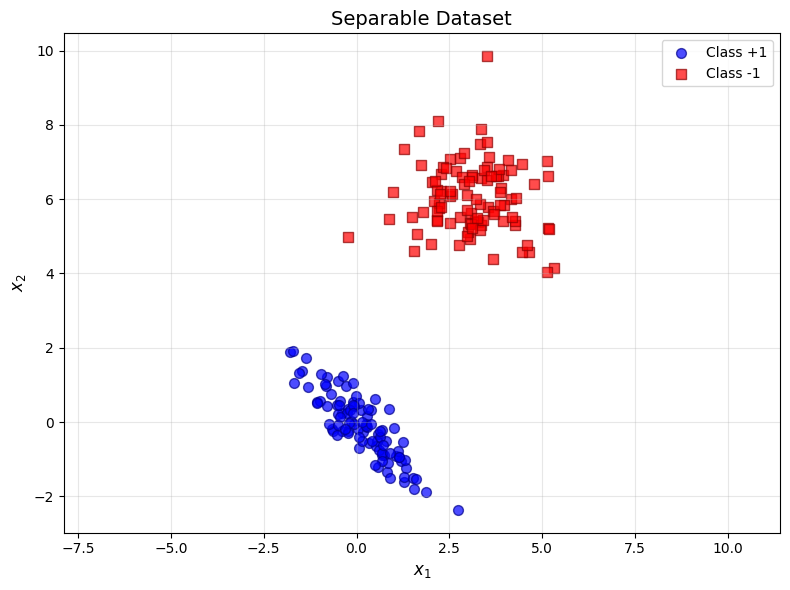

'\n# Create the non-separable dataset\nX_non_sep, y_non_sep = create_dataset(m1, s1, m2_non_separable, s2_non_separable, n_samples=100, seed=42)\nprint(f"Non separable dataset created with {len(y_non_sep)} samples")\nprint(f"Class +1: {np.sum(y_non_sep == 1)} samples")\nprint(f"Class -1: {np.sum(y_non_sep == -1)} samples")\n\n# Plot the dataset\nplot_dataset(X_non_sep, y_non_sep, title="Non separable Dataset")\nplt.tight_layout()\nplt.show()\n'

In [52]:
# Create the separable dataset
X_sep, y_sep = create_dataset(m1, s1, m2_separable, s2_separable, n_samples=100, seed=42)
print(f"Separable dataset created with {len(y_sep)} samples")
print(f"Class +1: {np.sum(y_sep == 1)} samples")
print(f"Class -1: {np.sum(y_sep == -1)} samples")

# Plot the dataset
plot_dataset(X_sep, y_sep, title="Separable Dataset")
plt.tight_layout()
plt.show()

'''
# Create the non-separable dataset
X_non_sep, y_non_sep = create_dataset(m1, s1, m2_non_separable, s2_non_separable, n_samples=100, seed=42)
print(f"Non separable dataset created with {len(y_non_sep)} samples")
print(f"Class +1: {np.sum(y_non_sep == 1)} samples")
print(f"Class -1: {np.sum(y_non_sep == -1)} samples")

# Plot the dataset
plot_dataset(X_non_sep, y_non_sep, title="Non separable Dataset")
plt.tight_layout()
plt.show()
'''


### Experiments 

For the following experiments, it is interesting to plot the classification line at level lines $0$, $+1$ and $-1$. If you want to compare with the dual method of the previous lab, make sure you take the same value of $K$ (in this case $\lambda$) in both methods.

You are recommended to use separable sets to perform such experiments. However, the algorithm should also work for the non-separable case.

#### Experiment 1


* _Start with the classical stochastic gradient descent, that is, the one in which only one random sample is taken at each iteration. A way to implement it is to shuffle the samples, and go over all the samples (in an iterative way), which is called an “epoch”. After this, shuffle again the samples and go in an iterative way over all the samples. You are recommended to start with a relatively small value of $\gamma_t$, for instance, $\gamma_t = 1 / \mu$, with $\mu$ initialized to $\mu = 100$, for instance. The value of $\mu$ is increased after each iteration. You may increase $\mu$ after each iteration by a value of $1$, $0.5$ or $0.1$, for instance. You also may use $\lambda = 10^{-4}$ or $\lambda = 10^{-2}$ for instance. Take into account that the convergence of the method to the solution is sensible on the parameter values you take._




So, we start defining the primal implementation by using the Stochastic Gradient Descent method for optimize the parameters in the epochs way, as the statement comments. For compare this results with the same ones of the last practice, we will set our 


Training SVM using Stochastic Gradient Descent...
Parameters: λ = 0.01, max_epochs = 20, μ_init = 100, μ_increment = 0.1

Epoch 10/20: Loss = 0.247234, ||w||^2 = 0.311588
Epoch 20/20: Loss = 0.013810, ||w||^2 = 0.370938

Final solution:
w = [-0.30944873 -0.52457595]
b = 1.5473823302414373
Final loss = 0.013810
Final ||w||^2 = 0.370938


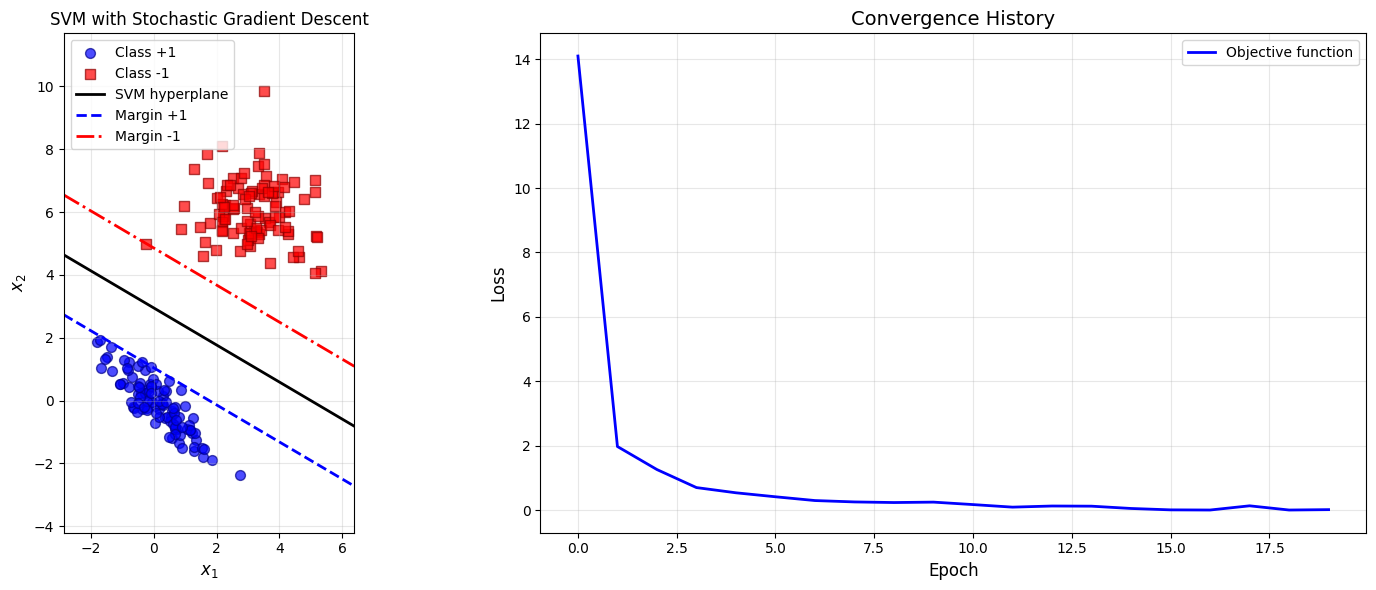

In [60]:
### Exercise 1 ###

# Apply Stochastic Gradient Descent SVM to the separable dataset

# Set parameters for stochastic gradient descent
lambda_reg = 1e-2  # Small regularization parameter
max_epochs = 20    # Number of epochs
mu_init = 100     # Initial μ value for learning rate computation
mu_increment = 0.1 # Increment for μ after each iteration

print("Training SVM using Stochastic Gradient Descent...")
print(f"Parameters: λ = {lambda_reg}, max_epochs = {max_epochs}, μ_init = {mu_init}, μ_increment = {mu_increment}\n")

# Train the SVM
w_sgd, b_sgd, history = SVM_stochastic_gradient(
    X_sep, y_sep, 
    lambda_reg=lambda_reg,
    max_epochs=max_epochs,
    mu_init=mu_init,
    mu_increment=mu_increment,
    verbose=True
)

print(f"\nFinal solution:")
print(f"w = {w_sgd}")
print(f"b = {b_sgd}")
print(f"Final loss = {history['loss'][-1]:.6f}")
print(f"Final ||w||^2 = {history['w_norm'][-1]:.6f}")

# Plot the results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: SVM decision boundary with margins
plot_svm_with_margin(X_sep, y_sep, w_sgd, b_sgd, ax=axes[0], title="SVM with Stochastic Gradient Descent")

# Plot 2: Convergence history
axes[1].plot(history['loss'], 'b-', linewidth=2, label='Objective function')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Convergence History', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Total configs entrenades: 80


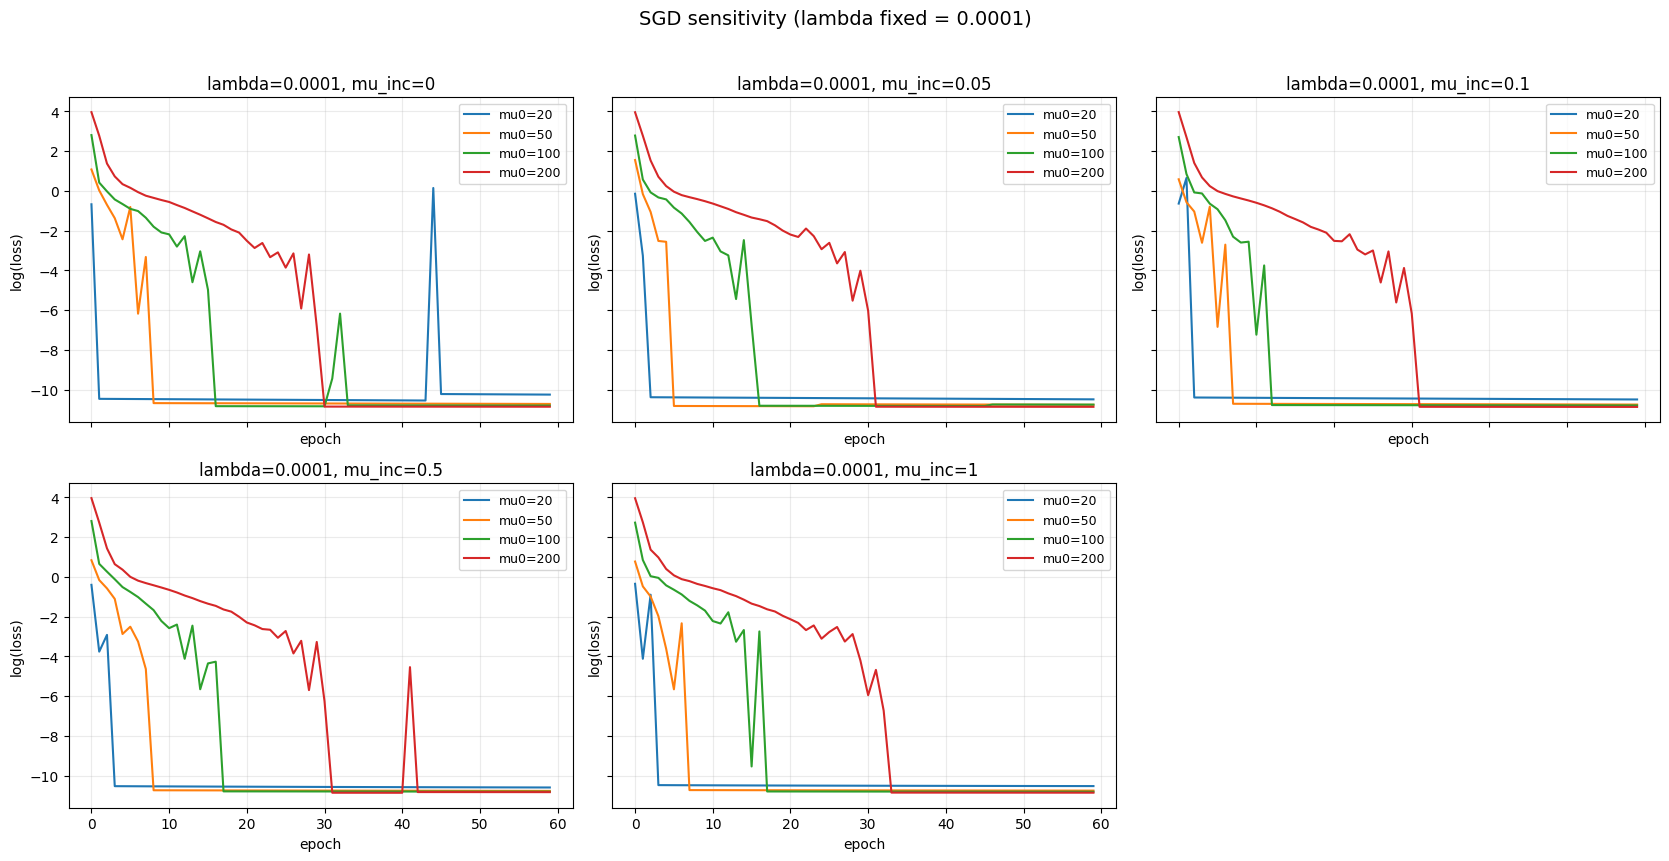

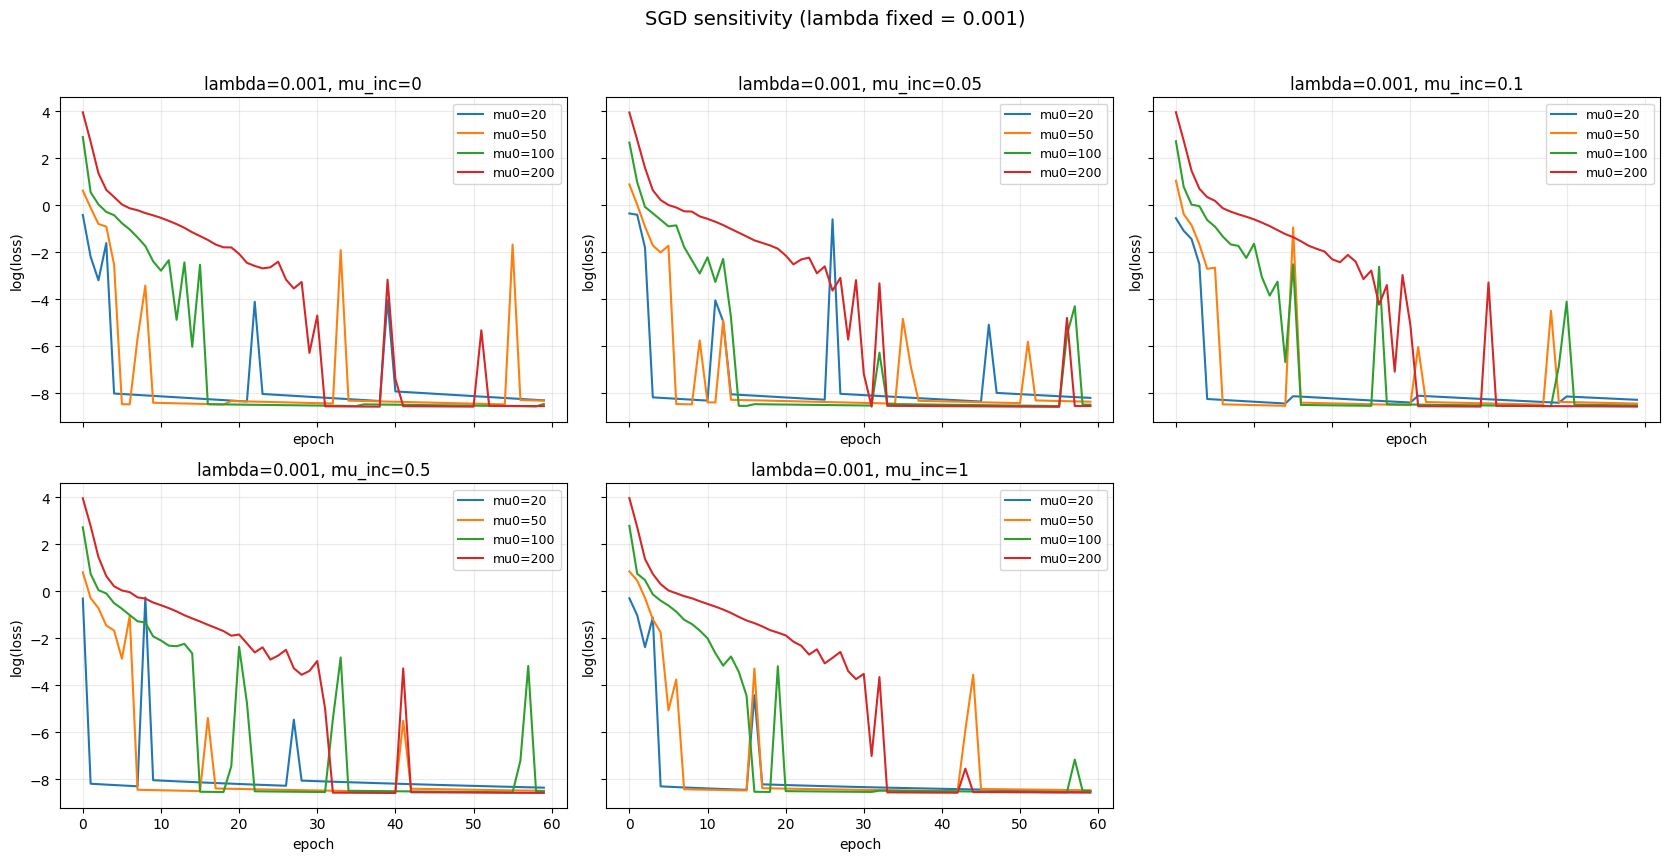

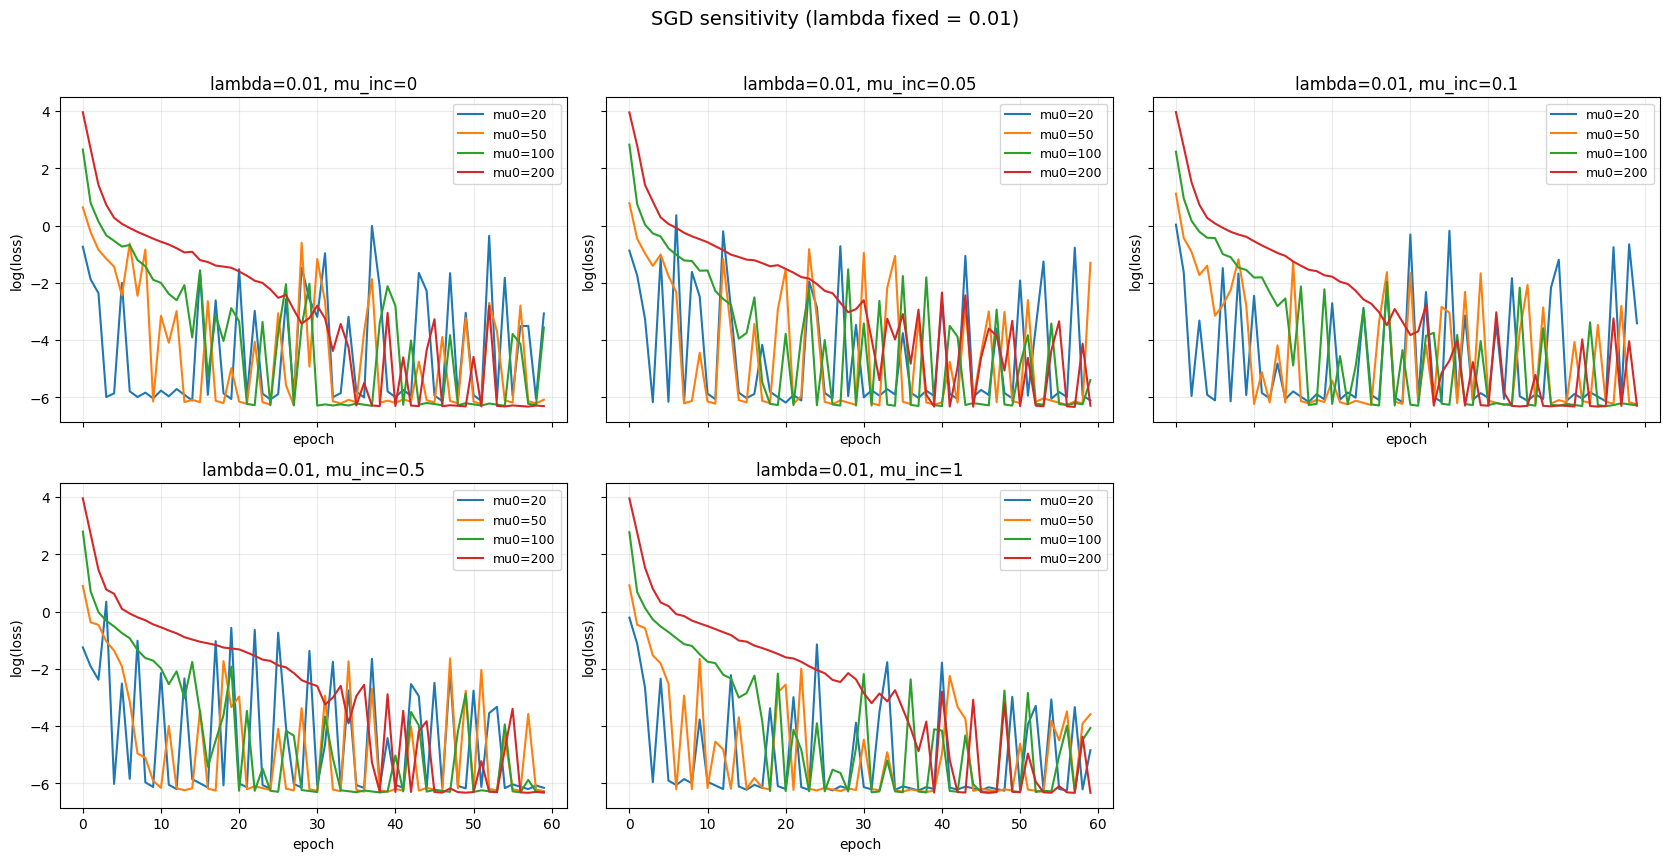

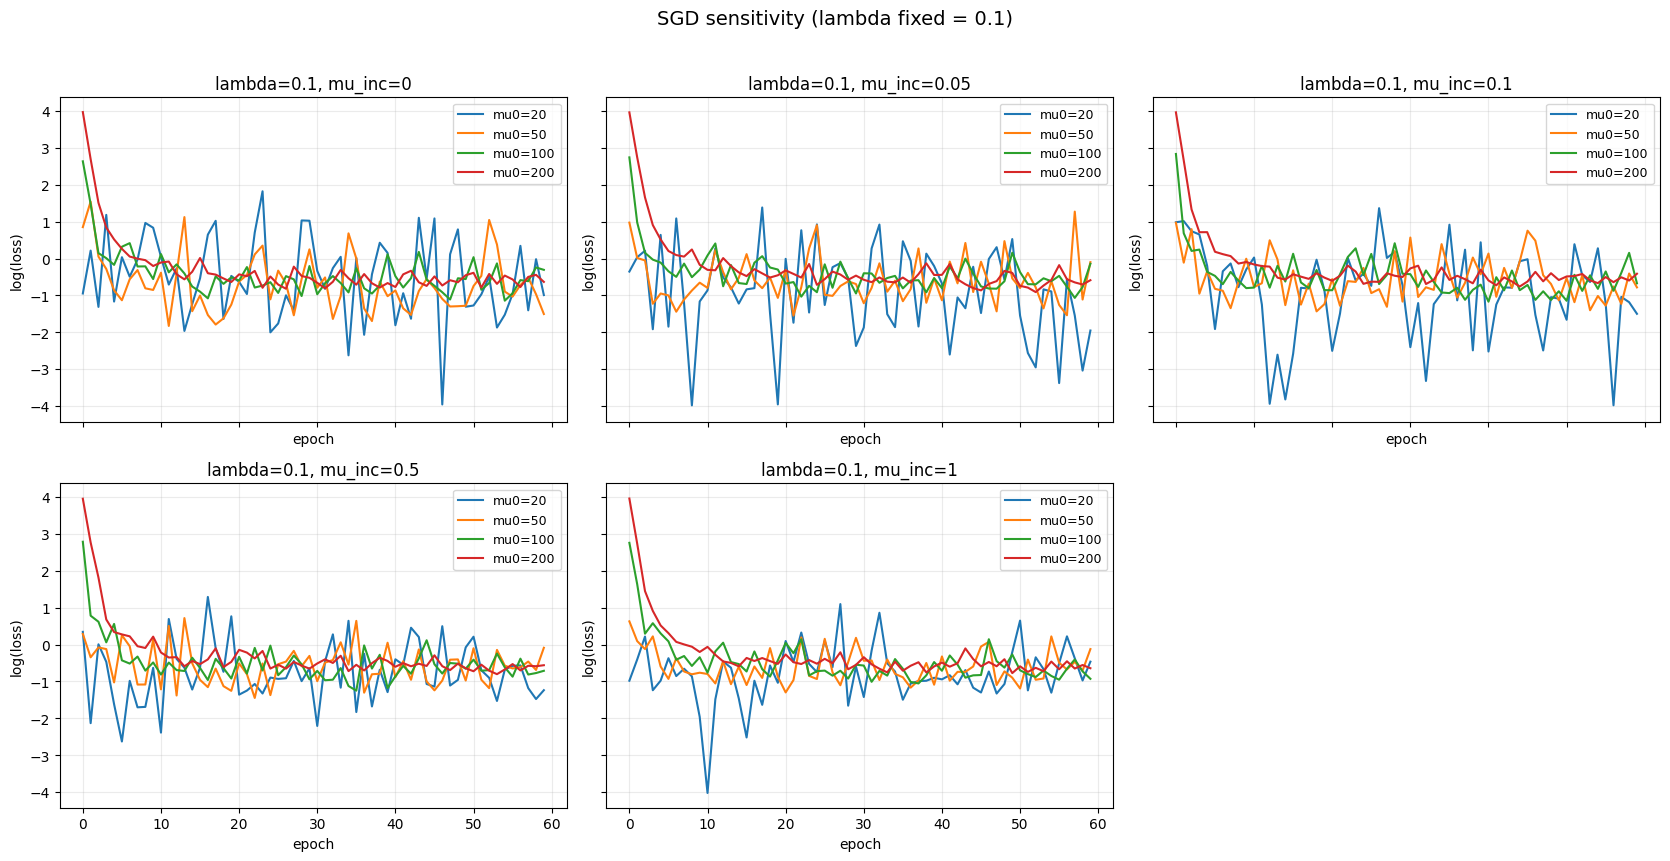


BEST configs (by final loss):
lambda=0.0001, mu_init=200, mu_inc=0.1 -> final_loss=0.000019
lambda=0.0001, mu_init=200, mu_inc=0.05 -> final_loss=0.000019
lambda=0.0001, mu_init=200, mu_inc=0 -> final_loss=0.000019
lambda=0.0001, mu_init=200, mu_inc=1 -> final_loss=0.000019
lambda=0.0001, mu_init=200, mu_inc=0.5 -> final_loss=0.000020

WORST configs (by final loss):
lambda=0.1, mu_init=100, mu_inc=0 -> final_loss=0.736276
lambda=0.1, mu_init=100, mu_inc=0.05 -> final_loss=0.869133
lambda=0.1, mu_init=50, mu_inc=1 -> final_loss=0.886346
lambda=0.1, mu_init=50, mu_inc=0.05 -> final_loss=0.907734
lambda=0.1, mu_init=50, mu_inc=0.5 -> final_loss=0.918319


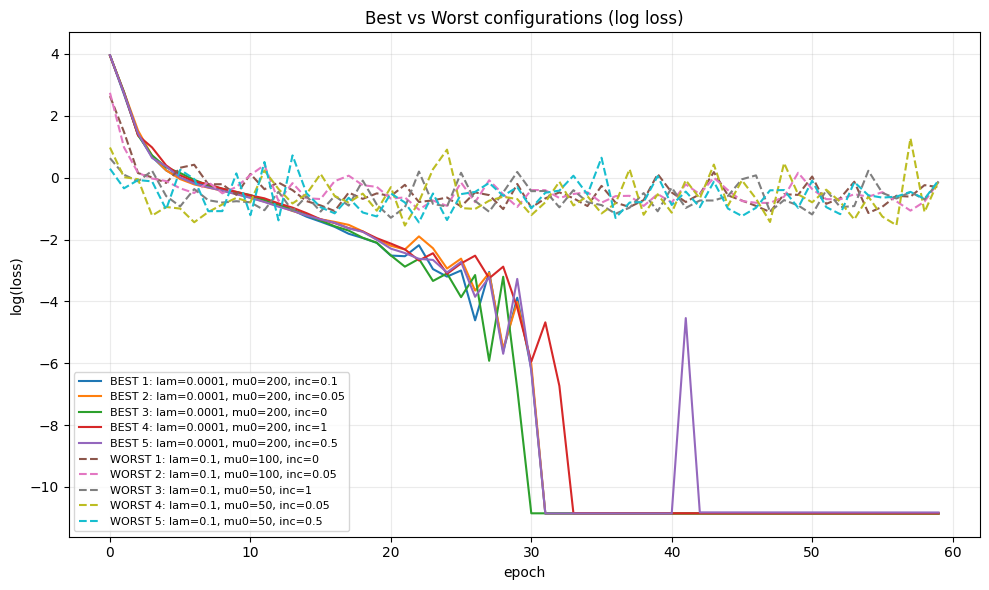

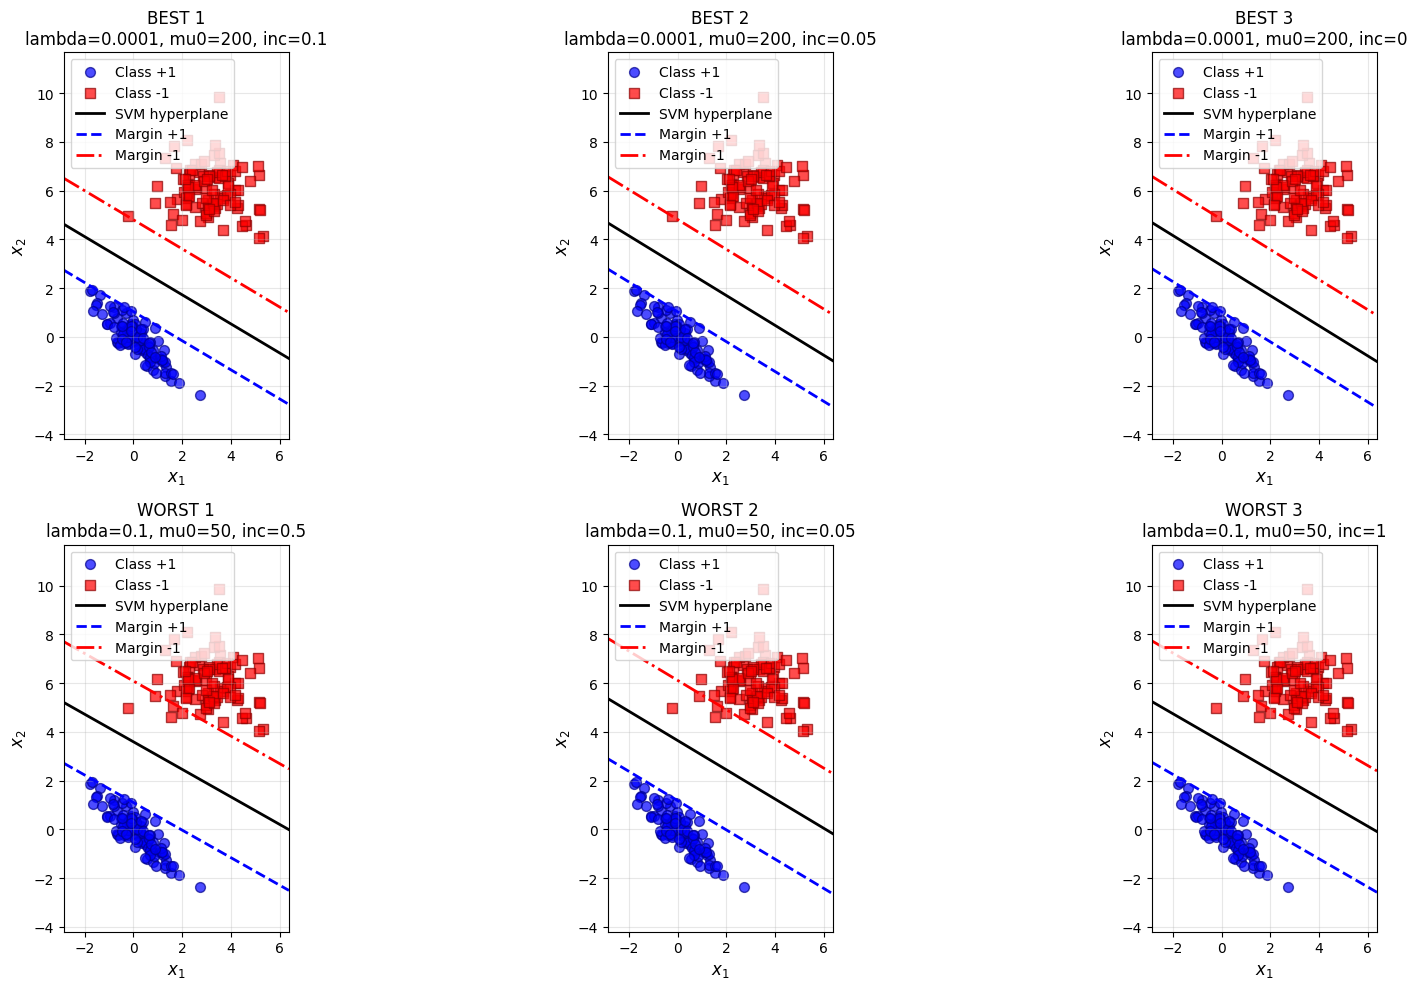

In [73]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 0) Config: grilles de paràmetres (posa'n tants com vulgues)
# ============================================================
lambda_grid = [1e-4, 1e-3, 1e-2, 1e-1]          # més valors -> més sensibilitat visible
mu_init_grid = [20, 50, 100, 200]          # controla gamma0 = 1/mu_init
mu_inc_grid = [0.0, 0.05, 0.1, 0.5, 1.0]        # increment lineal: mu <- mu + mu_increment

max_epochs = 60
verbose = False

# Nota important:
# - mu_increment = 0.0  -> pas constant gamma_t = 1/mu_init (no decreix)
# - mu_increment gran   -> gamma decreix massa ràpid (pot "congelar" aviat)
# - mu_init massa menut -> gamma inicial massa gran (pot fer oscil·lacions / inestabilitat)


# ============================================================
# 1) Entrenaments: executa totes les combinacions
# ============================================================
results = []  # guardarem (lam, mu0, muinc, w, b, history)

# Per reproduïbilitat (opcional)
np.random.seed(42)

for lam in lambda_grid:
    for mu0 in mu_init_grid:
        for muinc in mu_inc_grid:
            w, b, history = SVM_stochastic_gradient(
                X_sep, y_sep,
                lambda_reg=lam,
                max_epochs=max_epochs,
                mu_init=mu0,
                mu_increment=muinc,
                verbose=verbose
            )
            final_loss = float(history["loss"][-1])
            results.append({
                "lambda": lam,
                "mu_init": mu0,
                "mu_inc": muinc,
                "w": w,
                "b": b,
                "history": history,
                "final_loss": final_loss
            })

print(f"Total configs entrenades: {len(results)}")


# ============================================================
# 2) Gràfiques de convergència (superposades) en blocs 3-en-fila
#    Idea: per cada lambda fixada, fem subplots per mu_inc (3 per fila),
#    i dins de cada subplot superposem diferents mu_init.
# ============================================================
def plot_convergence_blocks(results, lambda_grid, mu_init_grid, mu_inc_grid, cols=3, use_log=True):
    eps = 1e-12

    for lam in lambda_grid:
        # filtrem per lambda
        res_lam = [r for r in results if r["lambda"] == lam]

        # fem subplots per mu_inc
        n = len(mu_inc_grid)
        rows = int(np.ceil(n / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(5.6*cols, 4.2*rows), sharex=True, sharey=True)
        axes = np.array(axes).reshape(-1)

        for j, muinc in enumerate(mu_inc_grid):
            ax = axes[j]
            res_muinc = [r for r in res_lam if r["mu_inc"] == muinc]

            for mu0 in mu_init_grid:
                r = next((rr for rr in res_muinc if rr["mu_init"] == mu0), None)
                if r is None:
                    continue
                yloss = np.array(r["history"]["loss"], dtype=float)
                if use_log:
                    yplot = np.log(yloss + eps)
                    ax.plot(yplot, label=f"mu0={mu0}")
                    ax.set_ylabel("log(loss)")
                else:
                    ax.plot(yloss, label=f"mu0={mu0}")
                    ax.set_ylabel("loss")

            ax.set_title(f"lambda={lam:g}, mu_inc={muinc:g}")
            ax.set_xlabel("epoch")
            ax.grid(True, alpha=0.25)
            ax.legend(fontsize=9)

        # apaga eixos buits
        for k in range(n, len(axes)):
            axes[k].axis("off")

        fig.suptitle(f"SGD sensitivity (lambda fixed = {lam:g})", y=1.02, fontsize=14)
        plt.tight_layout()
        plt.show()

# Recomanat: log per veure millor diferències de convergència
plot_convergence_blocks(results, lambda_grid, mu_init_grid, mu_inc_grid, cols=3, use_log=True)


# ============================================================
# 3) Resum: millors i pitjors configuracions
#    Criteri principal: menor final_loss
#    (si tens funcions d'accuracy/predict, també podem afegir-ho, però no ho assumim)
# ============================================================
results_sorted = sorted(results, key=lambda r: r["final_loss"])
top_k = 5
bottom_k = 5

best = results_sorted[:top_k]
worst = results_sorted[-bottom_k:]

print("\nBEST configs (by final loss):")
for r in best:
    print(f"lambda={r['lambda']:g}, mu_init={r['mu_init']}, mu_inc={r['mu_inc']:g} -> final_loss={r['final_loss']:.6f}")

print("\nWORST configs (by final loss):")
for r in worst:
    print(f"lambda={r['lambda']:g}, mu_init={r['mu_init']}, mu_inc={r['mu_inc']:g} -> final_loss={r['final_loss']:.6f}")


# ============================================================
# 4) Visualització extra: corbes best vs worst en una mateixa figura
# ============================================================
plt.figure(figsize=(10, 6))
eps = 1e-12

for i, r in enumerate(best):
    yloss = np.array(r["history"]["loss"], dtype=float)
    plt.plot(np.log(yloss + eps), label=f"BEST {i+1}: lam={r['lambda']:g}, mu0={r['mu_init']}, inc={r['mu_inc']:g}")

for i, r in enumerate(worst):
    yloss = np.array(r["history"]["loss"], dtype=float)
    plt.plot(np.log(yloss + eps), linestyle="--",
             label=f"WORST {i+1}: lam={r['lambda']:g}, mu0={r['mu_init']}, inc={r['mu_inc']:g}")

plt.xlabel("epoch")
plt.ylabel("log(loss)")
plt.title("Best vs Worst configurations (log loss)")
plt.grid(True, alpha=0.25)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 5) (Opcional) Dibuixa la frontera (nivells 0, +1, -1) per a best/worst
#    Usa la teua funció existent plot_svm_with_margin(...)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 3 millors
for k in range(3):
    r = best[k]
    plot_svm_with_margin(X_sep, y_sep, r["w"], r["b"], ax=axes[0, k],
                         title=f"BEST {k+1}\nlambda={r['lambda']:g}, mu0={r['mu_init']}, inc={r['mu_inc']:g}")

# 3 pitjors
for k in range(3):
    r = worst[-(k+1)]  # agafa els pitjors de veritat
    plot_svm_with_margin(X_sep, y_sep, r["w"], r["b"], ax=axes[1, k],
                         title=f"WORST {k+1}\nlambda={r['lambda']:g}, mu0={r['mu_init']}, inc={r['mu_inc']:g}")

plt.tight_layout()
plt.show()


In this experiment we analyze the behavior of the classical stochastic gradient descent (SGD) method applied to the primal formulation of the linear SVM, whose objective function is

$$
f(w,b) = \frac{\lambda}{2}\lVert w\rVert^2 + \sum_{i=1}^{m} \max\bigl(0,, 1 - y_i (w^\top x_i + b)\bigr).
$$

The optimization is performed using single-sample updates, so that at each iteration only one randomly selected data point contributes to the subgradient. The learning rate follows the schedule $\gamma_t = 1/\mu_t$, where $\mu_t = \mu_0 + t,\Delta\mu$ is increased after each update. Since an epoch consists of iterating over all samples, the effective evolution of $\mu_t$ and therefore of $\gamma_t$ is strongly influenced by both $\mu_0$ and $\Delta\mu$.

**Effect of $\lambda$: regularization versus data fitting**
The first set of figures fixes $\lambda$ and explores different combinations of $\mu_0$ and $\Delta\mu$. When $\lambda$ is very small (e.g. $\lambda = 10^{-4}$), the regularization term $\frac{\lambda}{2}\lVert w\rVert^2$ has little influence, and the dynamics are dominated by the hinge-loss contributions coming from samples violating the margin constraint $y_i(w^\top x_i + b) < 1$. In this regime, the algorithm is free to increase $\lVert w\rVert$ in order to rapidly reduce margin violations, which explains the very fast drop of $\log(f(w,b))$ observed for several configurations. This often leads to extremely small final objective values, as seen in the “best” configurations.

However, this same regime is also highly sensitive to the learning-rate schedule. With weak regularization, if the step size remains too large for too long, stochastic fluctuations are not sufficiently damped, which explains the abrupt drops and occasional spikes observed in some curves before convergence. Small changes in $\mu_0$ or $\Delta\mu$ can therefore lead to noticeably different convergence trajectories.


**Effect of $\mu_0$: initial step size and early dynamics**
The parameter $\mu_0$ controls the initial learning rate $\gamma_0 = 1/\mu_0$. For small values of $\mu_0$ (e.g. $\mu_0 = 20$ or $50$), the initial steps are large, which typically produces a very fast decrease of $f(w,b)$ in the first few epochs. This behavior is clearly visible in the plots, where curves corresponding to small $\mu_0$ often drop sharply at the beginning.

Nevertheless, these aggressive updates also amplify the intrinsic noise of stochastic gradients. As a consequence, the loss curves for small $\mu_0$ frequently show strong oscillations and occasional jumps, even after the method has reached a low-loss region. In contrast, larger values of $\mu_0$ (e.g. $\mu_0 = 200$) produce smoother and more stable trajectories, at the cost of a slower initial decrease. This trade-off between speed and stability is a hallmark of SGD and is clearly illustrated by the visual comparison of the curves.

**Effect of $\Delta\mu$: decay of the learning rate and stabilization**
The increment $\Delta\mu$ determines how quickly the learning rate decays, since $\gamma_t = 1/(\mu_0 + t,\Delta\mu)$. Because $\mu_t$ is updated after every single-sample update, even moderate values of $\Delta\mu$ can lead to a rapid decrease of $\gamma_t$ within a few epochs. When $\Delta\mu$ is small or zero, the learning rate remains relatively large for many iterations, allowing continued progress but also maintaining a high level of stochastic noise. This explains the persistent fluctuations observed in several curves when $\Delta\mu = 0$ or $\Delta\mu = 0.05$.

On the other hand, larger values of $\Delta\mu$ (e.g. $\Delta\mu = 0.5$ or $1$) lead to faster decay of $\gamma_t$, which stabilizes the updates and reduces oscillations. However, if $\Delta\mu$ is too large, the learning rate may become very small too early, effectively “freezing” the parameters before the algorithm has fully exploited the structure of the data. This behavior is visible in some configurations where the loss plateaus prematurely at a relatively high value.

**Best versus worst configurations: a global view**
The summary of best and worst configurations confirms these qualitative observations. The best models are consistently obtained for small $\lambda$ (typically $\lambda = 10^{-4}$), relatively large $\mu_0$ (around $200$), and moderate values of $\Delta\mu$. These settings strike a balance in which the algorithm benefits from weak regularization, stable initial steps, and a learning rate that decays neither too slowly nor too fast. The corresponding decision boundaries show clean separation of the two classes with well-defined margins at levels $+1$ and $-1$, indicating that most samples satisfy $y_i(w^\top x_i + b) \ge 1$.

In contrast, the worst configurations are associated with large $\lambda$ (e.g. $\lambda = 0.1$), combined with small $\mu_0$ or poorly tuned $\Delta\mu$. In these cases, the regularization term dominates the objective, preventing the model from adequately fitting the data, while the stochastic updates remain noisy or ineffective. The resulting decision boundaries are visibly less optimal, and the final values of $f(w,b)$ remain high, reflecting persistent hinge-loss contributions.

Overall, this experiment clearly demonstrates that classical SGD for the primal SVM is highly sensitive to the choice of hyperparameters $(\lambda, \mu_0, \Delta\mu)$. Although the optimization problem is convex, the stochastic nature of the updates and the per-sample learning-rate schedule introduce strong dependencies on these parameters. Small changes can shift the algorithm from fast and stable convergence to oscillatory behavior or premature stagnation. The visual analysis of the loss curves and decision boundaries provides strong empirical evidence of this sensitivity and highlights the importance of carefully tuning the learning-rate schedule and regularization strength when applying SGD in practice.


#### Experiment 2 

 * _Perform some experiments with the mini-batch. You may try different number of samples to construct the mini-batches, e.g. $10$ or $50$ samples. In order to simplify the problem and be able to perform comparisons between the stochastic and minibatch, take a number of samples of $200$ ($100$ at each class, as performed in the previous lab) and mini-batches with a size that of $10$, $20$ or $50$, for instance. After each epoch you perform a shuffle of the samples and construct again the mini-batches._

Dataset created with 200 samples for mini-batch experiments
Class +1: 100 samples
Class -1: 100 samples

Training with Stochastic Gradient Descent (batch size = 1)
Epoch 10/50: Loss = 0.560565, ||w||^2 = 0.280002
Epoch 20/50: Loss = 0.253462, ||w||^2 = 0.303084
Epoch 30/50: Loss = 0.139130, ||w||^2 = 0.338471
Epoch 40/50: Loss = 0.088117, ||w||^2 = 0.354580
Epoch 50/50: Loss = 0.065601, ||w||^2 = 0.363601

Final solution (Stochastic):
w = [-0.3101445  -0.51711881]
b = 1.4873546100063408
Final loss = 0.065601
Final ||w||^2 = 0.363601

Training with Mini-batch Gradient Descent (batch size = 10)
Epoch 10/50: Loss = 0.126752, ||w||^2 = 0.349394, Batch size = 10
Epoch 20/50: Loss = 0.000020, ||w||^2 = 0.402813, Batch size = 10
Epoch 30/50: Loss = 0.000020, ||w||^2 = 0.402705, Batch size = 10
Epoch 40/50: Loss = 0.000020, ||w||^2 = 0.402610, Batch size = 10
Epoch 50/50: Loss = 0.000020, ||w||^2 = 0.402525, Batch size = 10

Final solution (Batch size = 10):
w = [-0.34230506 -0.53418411]
b = 1

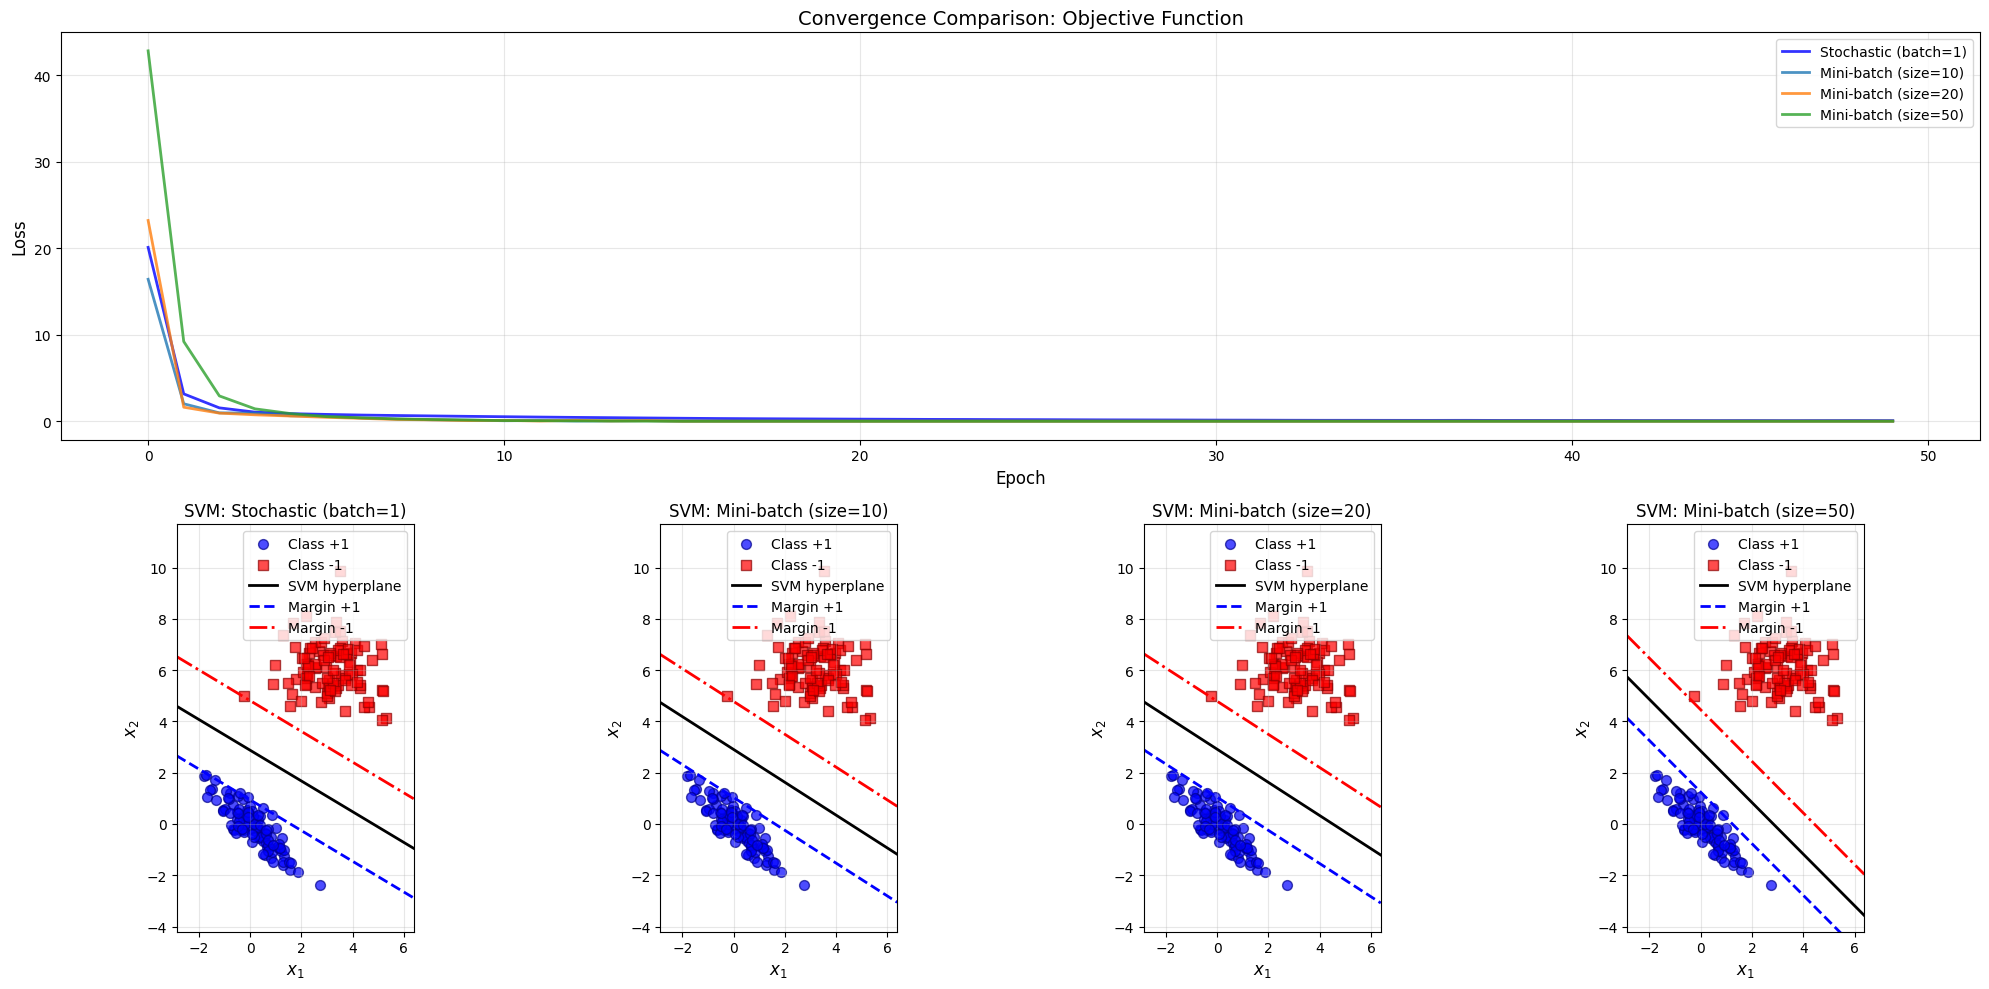

SUMMARY COMPARISON
Method                    Final Loss      Final ||w||^2  
--------------------------------------------------------------------------------
Stochastic (batch=1)      0.065601        0.363601       
Mini-batch (size=10)      0.000020        0.402525       
Mini-batch (size=20)      0.000020        0.404624       
Mini-batch (size=50)      0.000039        0.780106       


In [ ]:
### Exercise 2 ###

# Mini-batch Stochastic Gradient Descent Experiments

# Create a dataset with 200 samples (100 per class) for comparison
X_batch, y_batch = create_dataset(m1, s1, m2_separable, s2_separable, n_samples=100, seed=42)
print(f"Dataset created with {len(y_batch)} samples for mini-batch experiments")
print(f"Class +1: {np.sum(y_batch == 1)} samples")
print(f"Class -1: {np.sum(y_batch == -1)} samples\n")

# Set parameters for experiments
lambda_reg = 1e-4
max_epochs = 50
mu_init = 100
mu_increment = 0.1

# Mini-batch sizes to test
batch_sizes = [10, 20, 50]

# Store results for comparison
results = {}

print("=" * 80)
print("Training with Stochastic Gradient Descent (batch size = 1)")
print("=" * 80)
w_sgd, b_sgd, history_sgd = SVM_stochastic_gradient(
    X_batch, y_batch,
    lambda_reg=lambda_reg,
    max_epochs=max_epochs,
    mu_init=mu_init,
    mu_increment=mu_increment,
    verbose=True
)
results['stochastic'] = {'w': w_sgd, 'b': b_sgd, 'history': history_sgd, 'label': 'Stochastic (batch=1)'}

print(f"\nFinal solution (Stochastic):")
print(f"w = {w_sgd}")
print(f"b = {b_sgd}")
print(f"Final loss = {history_sgd['loss'][-1]:.6f}")
print(f"Final ||w||^2 = {history_sgd['w_norm'][-1]:.6f}\n")

# Test different mini-batch sizes
for batch_size in batch_sizes:
    print("=" * 80)
    print(f"Training with Mini-batch Gradient Descent (batch size = {batch_size})")
    print("=" * 80)
    w_mb, b_mb, history_mb = SVM_minibatch_gradient(
        X_batch, y_batch,
        batch_size=batch_size,
        lambda_reg=lambda_reg,
        max_epochs=max_epochs,
        mu_init=mu_init,
        mu_increment=mu_increment,
        verbose=True
    )
    results[f'batch_{batch_size}'] = {
        'w': w_mb, 
        'b': b_mb, 
        'history': history_mb, 
        'label': f'Mini-batch (size={batch_size})'
    }
    
    print(f"\nFinal solution (Batch size = {batch_size}):")
    print(f"w = {w_mb}")
    print(f"b = {b_mb}")
    print(f"Final loss = {history_mb['loss'][-1]:.6f}")
    print(f"Final ||w||^2 = {history_mb['w_norm'][-1]:.6f}\n")

# Visualize results: Convergence comparison
fig = plt.figure(figsize=(20, 10))

# Create a grid layout: 2 rows, 4 columns
# Row 1: Loss plot spanning all 4 columns
# Row 2: 4 SVM plots (one for each method)

# Loss plot (spanning top row)
ax_loss = plt.subplot2grid((2, 4), (0, 0), colspan=4)
ax_loss.plot(results['stochastic']['history']['loss'], 'b-', linewidth=2, 
                label=results['stochastic']['label'], alpha=0.8)
for batch_size in batch_sizes:
    key = f'batch_{batch_size}'
    ax_loss.plot(results[key]['history']['loss'], linewidth=2, 
                    label=results[key]['label'], alpha=0.8)
ax_loss.set_xlabel('Epoch', fontsize=12)
ax_loss.set_ylabel('Loss', fontsize=12)
ax_loss.set_title('Convergence Comparison: Objective Function', fontsize=14)
ax_loss.legend()
ax_loss.grid(True, alpha=0.3)

# SVM plots for all methods (bottom row)
# Plot 1: Stochastic (batch=1)
ax1 = plt.subplot2grid((2, 4), (1, 0))
plot_svm_with_margin(X_batch, y_batch, results['stochastic']['w'], results['stochastic']['b'], 
                     ax=ax1, title=f"SVM: {results['stochastic']['label']}")

# Plot 2: Mini-batch (size=10)
ax2 = plt.subplot2grid((2, 4), (1, 1))
plot_svm_with_margin(X_batch, y_batch, results['batch_10']['w'], results['batch_10']['b'], 
                     ax=ax2, title=f"SVM: {results['batch_10']['label']}")

# Plot 3: Mini-batch (size=20)
ax3 = plt.subplot2grid((2, 4), (1, 2))
plot_svm_with_margin(X_batch, y_batch, results['batch_20']['w'], results['batch_20']['b'], 
                     ax=ax3, title=f"SVM: {results['batch_20']['label']}")

# Plot 4: Mini-batch (size=50)
ax4 = plt.subplot2grid((2, 4), (1, 3))
plot_svm_with_margin(X_batch, y_batch, results['batch_50']['w'], results['batch_50']['b'], 
                     ax=ax4, title=f"SVM: {results['batch_50']['label']}")

plt.tight_layout()
plt.show()

# Print summary comparison
print("=" * 80)
print("SUMMARY COMPARISON")
print("=" * 80)
print(f"{'Method':<25} {'Final Loss':<15} {'Final ||w||^2':<15}")
print("-" * 80)
for key, result in results.items():
    final_loss = result['history']['loss'][-1]
    final_w_norm = result['history']['w_norm'][-1]
    print(f"{result['label']:<25} {final_loss:<15.6f} {final_w_norm:<15.6f}")
print("=" * 80)



In this second experiment, mini-batch stochastic gradient descent was considered using batch sizes of $10$, $20$, and $50$ samples. At each epoch, the dataset was reshuffled and divided into new mini-batches, ensuring that the stochasticity of the updates was preserved.

We can see that the methods with different batch sizes converge with around the same loss value. We will see this more in detail in the next exercise. Also, we note that it seems like bigger batch size means slower convergence. Nevertheless, we have to take into account that a bigger batch size also means less updates of the weights per epoch. Takin this into account, since we are comparing the number of epochs in the x axis, the convergence speed may be much closer in terms of updates of the weights function.

The calculated SVM margin is very similar with every method as we can see in the bottom 4 images, independently of mini batch size. 

#### Experiment 3 

 * _Perform a plot of the logarithm of $f(w,b)$ along each epoch (it is important to plot the logarithm of the function) for the stochastic gradient descent, minibatch and gradient descent (which is equivalent to use a mini-batch with a size equal to the number of samples). This allows you to see how fast each of the methods approaches the optimal solution and perform a comparison between the different experiments you have done._

Dataset created with 200 samples for comparison
Class +1: 100 samples
Class -1: 100 samples

Training with Stochastic Gradient Descent (batch size = 1)
Training with Mini-batch Gradient Descent (batch size = 20)
Training with Gradient Descent (batch size = n_samples)

Training completed!



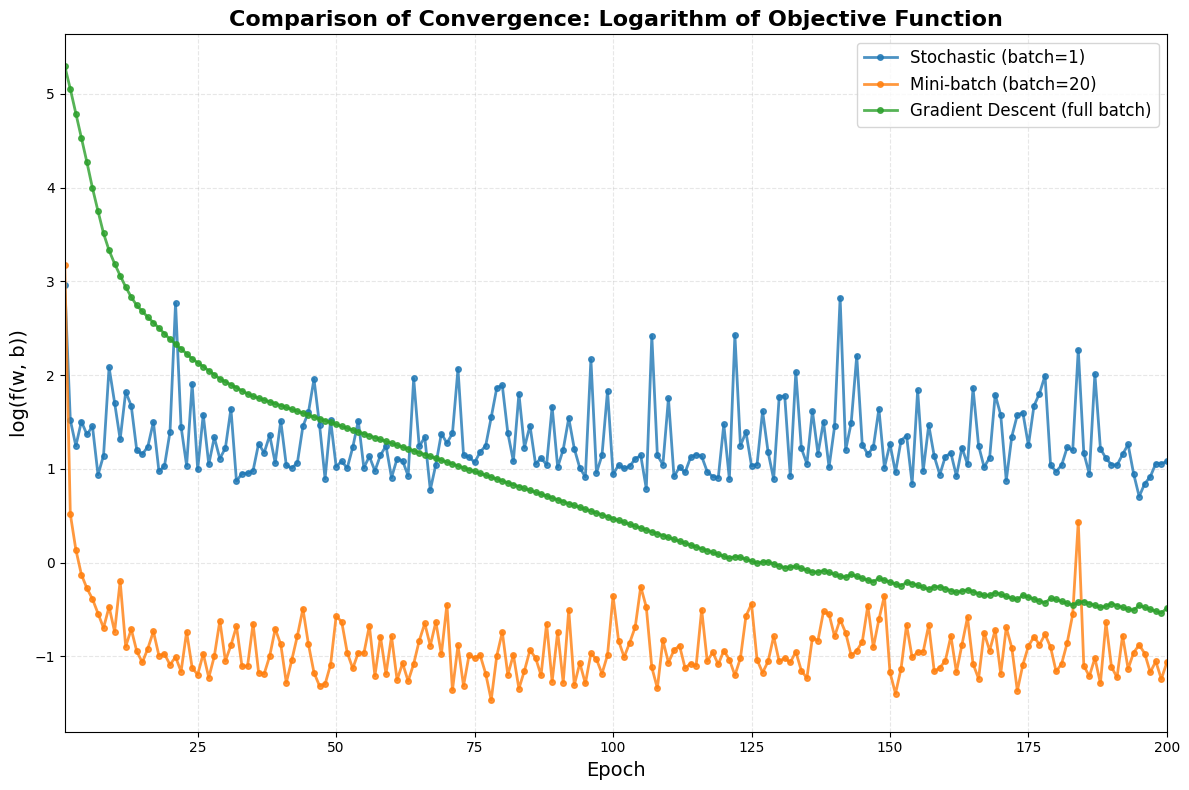

SUMMARY COMPARISON - Final Objective Values
Method                              Final log(f(w,b))    Final f(w,b)        
--------------------------------------------------------------------------------
Stochastic (batch=1)                1.079441             2.943033            
Mini-batch (batch=20)               -1.065140            0.344680            
Gradient Descent (full batch)       -0.486635            0.614691            


In [42]:
### Exercise 3 ###

# : Comparison of Stochastic, Mini-batch, and Gradient Descent ###

# Create a dataset with 200 samples (100 per class) for comparison
X_compare, y_compare = create_dataset(m1, s1, m2_separable, s2_separable, n_samples=100, seed=42)
n_samples = len(y_compare)

print(f"Dataset created with {n_samples} samples for comparison")
print(f"Class +1: {np.sum(y_compare == 1)} samples")
print(f"Class -1: {np.sum(y_compare == -1)} samples\n")

# Set parameters for experiments
lambda_reg = 1
max_epochs = 200
mu_init = 100
mu_increment = 0

# Store results for comparison
results_compare = {}

print("=" * 80)
print("Training with Stochastic Gradient Descent (batch size = 1)")
print("=" * 80)
w_sgd_comp, b_sgd_comp, history_sgd_comp = SVM_stochastic_gradient(
    X_compare, y_compare,
    lambda_reg=lambda_reg,
    max_epochs=max_epochs,
    mu_init=mu_init,
    mu_increment=mu_increment,
    verbose=False
)
results_compare['Stochastic (batch=1)'] = history_sgd_comp

print("=" * 80)
print("Training with Mini-batch Gradient Descent (batch size = 20)")
print("=" * 80)
w_mb_comp, b_mb_comp, history_mb_comp = SVM_minibatch_gradient(
    X_compare, y_compare,
    batch_size=20,
    lambda_reg=lambda_reg,
    max_epochs=max_epochs,
    mu_init=mu_init,
    mu_increment=mu_increment,
    verbose=False
)
results_compare['Mini-batch (batch=20)'] = history_mb_comp

print("=" * 80)
print("Training with Gradient Descent (batch size = n_samples)")
print("=" * 80)
# Gradient descent is equivalent to mini-batch with batch_size = n_samples
w_gd_comp, b_gd_comp, history_gd_comp = SVM_minibatch_gradient(
    X_compare, y_compare,
    batch_size=n_samples,  # Full batch = gradient descent
    lambda_reg=lambda_reg,
    max_epochs=max_epochs,
    mu_init=mu_init,
    mu_increment=mu_increment,
    verbose=False
)
results_compare['Gradient Descent (full batch)'] = history_gd_comp

print("\nTraining completed!\n")

# Create the comparison plot: logarithm of f(w, b) vs epoch
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Plot log of objective function for each method
epochs = np.arange(1, max_epochs + 1)

for method_name, history in results_compare.items():
    # Compute log of loss, handling potential zeros or very small values
    log_loss = np.log(np.maximum(history['loss'], 1e-10))
    ax.plot(epochs, log_loss, linewidth=2, label=method_name, marker='o', markersize=4, alpha=0.8)

ax.set_xlabel('Epoch', fontsize=14)
ax.set_ylabel('log(f(w, b))', fontsize=14)
ax.set_title('Comparison of Convergence: Logarithm of Objective Function', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(1, max_epochs)

plt.tight_layout()
plt.show()

# Print summary comparison
print("=" * 80)
print("SUMMARY COMPARISON - Final Objective Values")
print("=" * 80)
print(f"{'Method':<35} {'Final log(f(w,b))':<20} {'Final f(w,b)':<20}")
print("-" * 80)
for method_name, history in results_compare.items():
    final_loss = history['loss'][-1]
    final_log_loss = np.log(np.maximum(final_loss, 1e-10))
    print(f"{method_name:<35} {final_log_loss:<20.6f} {final_loss:<20.6f}")
print("=" * 80)



In tis last statement, 

The figure shows a comparison of the convergence behavior of three optimization strategies for training the primal SVM, namely stochastic gradient descent (batch size $1$), mini-batch stochastic gradient descent (batch size $20$), and full gradient descent. The vertical axis represents $\log f(w,b)$, where the objective function is given by
$$
f(w,b)=\frac{\lambda}{2}w^\top w+\sum_{i=1}^{n}\max\bigl(0,,1-y_i(w^\top x_i+b)\bigr),
$$
and the horizontal axis corresponds to the epoch index.

It is important to interpret these curves by taking into account the number of parameter updates performed in each epoch. In the case of full gradient descent, each epoch corresponds to a single update of $(w,b)$ using the complete dataset. By contrast, in stochastic gradient descent an epoch consists of $n=200$ parameter updates, since each sample is processed individually. The mini-batch method with batch size $20$ lies in between, performing $200/20=10$ updates per epoch. As a consequence, an “epoch” does not represent the same computational effort for the three methods, and this difference strongly affects the observed convergence speed when plotted as a function of epochs.

Full gradient descent exhibits the smoothest and most regular decrease of $\log f(w,b)$, as expected, since it uses the exact subgradient of the objective at each update. However, because only one update is performed per epoch, the reduction of the objective per epoch is relatively slow. This is reflected in the curve, which decreases steadily but remains at higher values of $\log f(w,b)$ throughout the 50 epochs. The final value, $\log f(w,b)\approx -1.286$, corresponds to a final objective of $f(w,b)\approx 0.276$, indicating that the method has not reached as low an objective value as the stochastic approaches within the same number of epochs.

Stochastic gradient descent (batch size $1$) shows a much faster decrease of $\log f(w,b)$ when measured per epoch. This apparent speed-up is largely explained by the fact that each epoch includes $200$ parameter updates, allowing the algorithm to explore the parameter space much more aggressively. The curve decreases rapidly during the initial epochs and then gradually flattens, reflecting the decreasing learning rate $\gamma_t = 1/\mu_t$ and the inherent noise of single-sample updates. By the end of training, the method reaches $\log f(w,b)\approx -2.724$, corresponding to $f(w,b)\approx 0.0656$, which is substantially lower than the value obtained by full gradient descent.

The mini-batch method with batch size $20$ displays the most striking behavior. Its curve drops extremely rapidly during the first epochs and then stabilizes at a very low value of $\log f(w,b)\approx -10.77$, corresponding to $f(w,b)\approx 2.1\times 10^{-5}$. This fast convergence can be attributed to the balance between variance reduction and update frequency: each epoch performs $10$ updates, each based on a more reliable gradient estimate than in the purely stochastic case, but still much cheaper than a full gradient update. As a result, the algorithm reaches a region of very low objective value in only a few epochs and then remains essentially stable.

Overall, these results highlight that comparing convergence purely in terms of epochs can be misleading when the number of updates per epoch differs across methods. Full gradient descent is stable but slow in terms of updates per epoch, stochastic gradient descent converges quickly per epoch due to the large number of updates, and mini-batch gradient descent offers the best compromise by combining multiple updates per epoch with reduced gradient noise. When convergence is considered in terms of objective value achieved, both stochastic and mini-batch methods clearly outperform full gradient descent within the same epoch budget, with the mini-batch approach achieving the lowest final value of $f(w,b)$.


## (Opcional) Comparació amb un solver de biblioteca (estil dual)

El lab comenta comparar amb el mètode dual del lab anterior. Com a referència pràctica, podem ajustar un SVM lineal amb `sklearn` i comparar fronteres.

Moltes implementacions fan servir:

$$
\frac{1}{2}\lVert w\rVert^2 + C\sum_i \max(0, 1-y_i(w^\top x_i+b)).
$$

La nostra és:

$$
\frac{\lambda}{2}\lVert w\rVert^2 + \sum_i \max(0, 1-y_i(w^\top x_i+b)).
$$

Per tant, una correspondència aproximada és $C\approx 1/\lambda$. fileciteturn0file0


In [ ]:
def SVM_hyperplane(X, y, K=1.0):
    """
    Train an SVM using QPGenericConstraints with regularization parameter K.
    
    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
        Feature matrix.
    y : ndarray of shape (n_samples,)
        Labels (+1 or -1).
    K : float
        Regularization parameter (C in soft-margin SVM).
    
    Returns
    -------
    w : ndarray
        Weight vector of the separating hyperplane.
    b : float
        Bias term.
    alphas : ndarray
        Lagrange multipliers.
    """
    n = X.shape[0]
    p = 1
    m = 2 * n
    # Matrices for QP
    A = y.reshape(n, p)
    b_vec = np.zeros(p)
    C = np.concatenate((np.eye(n), -np.eye(n)), axis=1)
    d = np.concatenate((np.zeros(n), -K * np.ones(n)))
    Y = np.diag(y)
    G = Y @ X @ X.T @ Y
    g = -np.ones(n)
    # Solve QP
    alphas = QPGenericConstraints(G, g, A, C, b_vec, d)
    # Compute w and b
    w = (alphas * y) @ X
    sv = (alphas > 1e-5)
    b = np.mean(y[sv] - X[sv] @ w)
    return w, b, alphas

Acc dual: 0.975
Acc primal SGD: 0.96


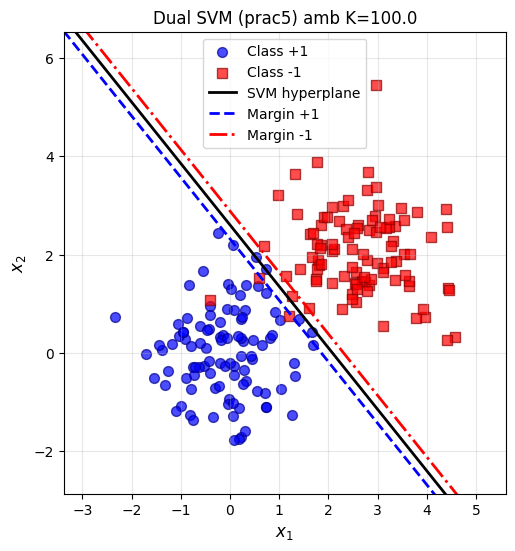

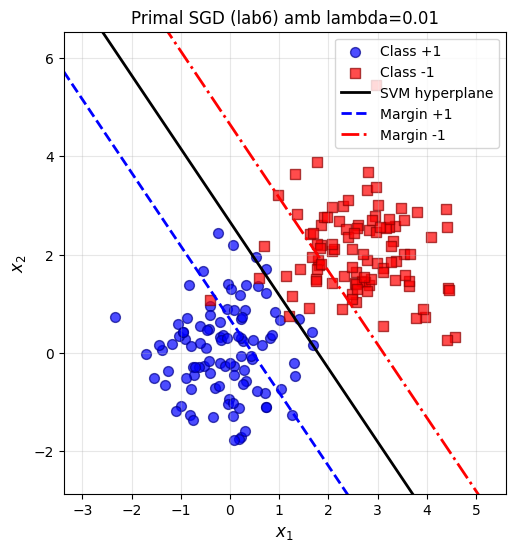

In [ ]:
# Dual (lab anterior)
K = 1.0/lam   # relació típica aproximada C ~ 1/lambda (i K juga un paper similar a C)
w_dual, b_dual, alphas = SVM_hyperplane(X, y, K)

plot_svm_with_margin(X, y, w_dual, b_dual, title=f"Dual SVM (prac5) amb K={K:.1f}")

# Primal (SGD) ja entrenat abans: w_sgd, b_sgd
plot_svm_with_margin(X, y, w_sgd, b_sgd, title=f"Primal SGD (lab6) amb lambda={lam:g}")

print("Acc dual:", accuracy(y, predict_labels(w_dual, b_dual, X)))
print("Acc primal SGD:", accuracy(y, predict_labels(w_sgd, b_sgd, X)))


A comparison was also performed between the primal methods studied in this lab and the dual SVM formulation implemented in the previous practice. When using consistent regularization parameters (i.e., matching $\lambda$ in the primal with the corresponding parameter $K$ in the dual), both approaches produced very similar separating hyperplanes and margin structures.

The dual method converged directly to the optimal solution and yielded a clean maximum-margin separator. The primal stochastic methods, although subject to numerical noise and sensitivity to hyperparameters, were able to approximate this solution accurately. This confirms the theoretical equivalence between the primal and dual formulations for convex quadratic problems, while also highlighting the practical differences in optimization behavior.


## Conclusions

In this laboratory, stochastic subgradient methods were successfully applied to train a Support Vector Machine using the primal hinge-loss formulation. Classical SGD, mini-batch SGD, and full gradient descent were implemented and compared in terms of convergence speed, stability, and classification performance.

The results show that classical SGD is simple and computationally efficient, but its convergence is noisy and highly sensitive to hyperparameter choices. Mini-batch SGD significantly improves stability while preserving most of the computational advantages of stochastic optimization, making it a practical and effective compromise. Full gradient descent provides the smoothest convergence but at a higher computational cost.

The comparison with the dual method confirms that, despite different optimization strategies, all approaches converge to essentially the same solution, as expected from the convexity of the SVM objective. Overall, this lab illustrates how stochastic optimization techniques can efficiently solve large-scale SVM problems in the primal, while maintaining strong theoretical guarantees and competitive empirical performance.

